# English Model Training

In [ ]:
%pip -q install transformers==4.44.2 datasets==3.0.1 accelerate==0.34.2 evaluate==0.4.2 scikit-learn==1.5.2

In [ ]:
import os, random, re
import numpy as np
import pandas as pd
from typing import List, Dict

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

from transformers import (
    AutoTokenizer, AutoConfig, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments, EarlyStoppingCallback
)

# ----------------- Repro & Device -----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ----------------- Labels -----------------
TARGET_LABELS: List[str] = [
    "anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"
]
label2id: Dict[str, int] = {l: i for i, l in enumerate(TARGET_LABELS)}
id2label: Dict[int, str] = {i: l for l, i in label2id.items()}

# ----------------- Paths -----------------
MELD_TRAIN = "/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/train/train_sent_emo.csv"
MELD_DEV   = "/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/dev_sent_emo.csv"
MELD_TEST  = "/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/test_sent_emo.csv"

TEXT_SENTIMENT = "/kaggle/input/text-sentiment/main.csv"

EMO_DESC_XLSX  = "/kaggle/input/emotions-description/Emotions description.xlsx"
EMO_DESC_SHEET = "List1"

EMO_TRAIN = "/kaggle/input/emotion-dataset/training.csv"
EMO_VAL   = "/kaggle/input/emotion-dataset/validation.csv"
EMO_TEST  = "/kaggle/input/emotion-dataset/test.csv"
EMO_MAP   = {0:'sadness', 1:'joy', 2:'love', 3:'anger', 4:'fear', 5:'surprise'}  # no neutral here

# ----------------- Loaders for each source -----------------
def clean_text(s):
    return str(s).replace("\n", " ").replace("\r", " ").strip()

def load_meld_csv(path):
    df = pd.read_csv(path)
    if "Utterance" not in df.columns or "Emotion" not in df.columns:
        raise ValueError(f"MELD CSV must contain 'Utterance' and 'Emotion' columns. Got: {df.columns.tolist()}")
    df["Emotion"] = df["Emotion"].str.lower().str.strip().replace({
        "happiness": "joy",
        "sad": "sadness",
        "angry": "anger",
        "surprised": "surprise"
    })
    df["text"]  = df["Utterance"].map(clean_text)
    df["label"] = df["Emotion"]
    df = df[["text", "label"]]
    df = df[df["label"].isin(TARGET_LABELS)].reset_index(drop=True)
    return df

def load_text_sentiment_csv(path):
    df = pd.read_csv(path)
    if not {"text", "label"}.issubset(df.columns):
        raise ValueError(f"text-sentiment CSV must contain 'text' and 'label'. Got: {df.columns.tolist()}")
    df["label"] = df["label"].str.lower().str.strip()
    df["text"]  = df["text"].map(clean_text)
    df = df[df["label"].isin(TARGET_LABELS)].reset_index(drop=True)
    return df

def load_emotions_description_xlsx(path, sheet="List1"):
    df = pd.read_excel(path, sheet_name=sheet)
    if not {"Field1", "SIT"}.issubset(df.columns):
        raise ValueError(f"Emotions description sheet must contain 'Field1' and 'SIT'. Got: {df.columns.tolist()}")
    df["label"] = df["Field1"].astype(str).str.lower().str.strip()
    df["text"]  = df["SIT"].map(clean_text)
    df = df[["text", "label"]]
    df = df[df["label"].isin(TARGET_LABELS)].reset_index(drop=True)  # drop guilt/shame/etc.
    return df

def load_emotion_dataset_csv(path):
    df = pd.read_csv(path)
    if "label" not in df.columns or "text" not in df.columns:
        raise ValueError(f"emotion-dataset CSV must contain 'text' and 'label' (numeric). Got: {df.columns.tolist()}")
    df["label"] = df["label"].map(EMO_MAP)  # map to names
    df["text"]  = df["text"].map(clean_text)
    df = df[df["label"].isin(TARGET_LABELS)].reset_index(drop=True)  # drops 'love'
    return df

# ----------------- Build Combined Splits -----------------
# Strategy:
#   Train = MELD train + emotion-dataset training + ALL text-sentiment + ALL emotions-description/List1
#   Dev   = MELD dev + emotion-dataset validation
#   Test  = MELD test + emotion-dataset test
meld_train_df = load_meld_csv(MELD_TRAIN)
meld_dev_df   = load_meld_csv(MELD_DEV)
meld_test_df  = load_meld_csv(MELD_TEST)

ts_df         = load_text_sentiment_csv(TEXT_SENTIMENT)
ed_df         = load_emotions_description_xlsx(EMO_DESC_XLSX, EMO_DESC_SHEET)

emo_train_df  = load_emotion_dataset_csv(EMO_TRAIN)
emo_val_df    = load_emotion_dataset_csv(EMO_VAL)
emo_test_df   = load_emotion_dataset_csv(EMO_TEST)

train_df = pd.concat([meld_train_df, emo_train_df, ts_df, ed_df], ignore_index=True)
dev_df   = pd.concat([meld_dev_df,   emo_val_df],               ignore_index=True)
test_df  = pd.concat([meld_test_df,  emo_test_df],              ignore_index=True)

print("Train size:", len(train_df), " Dev size:", len(dev_df), " Test size:", len(test_df))
print("\nTrain label distribution:")
print(train_df["label"].value_counts().sort_index())

# ----------------- Dataset -----------------
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df["text"].tolist()
        self.labels = [label2id[l] for l in df["label"].tolist()]
        self.tok = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_length,
            truncation=True,
            padding=False
        )
        enc["labels"] = self.labels[idx]
        return enc

# ----------------- Tokenizer / Model -----------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=len(TARGET_LABELS),
    id2label=id2label,
    label2id=label2id,
    problem_type="single_label_classification"
)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, config=config).to(DEVICE)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_ds = TextDataset(train_df, tokenizer, max_length=128)
dev_ds   = TextDataset(dev_df,   tokenizer, max_length=128)
test_ds  = TextDataset(test_df,  tokenizer, max_length=128)

2025-10-12 10:23:20.651281: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760264600.835972     101 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760264600.894317     101 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Device: cuda
Train size: 92058  Dev size: 2931  Test size: 4451

Train label distribution:
label
anger       10931
disgust      1367
fear         6932
joy         18275
neutral     29369
sadness     19474
surprise     5710
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# =========================
# CLASS WEIGHTS + MACRO RECALL
# =========================
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

# --- Compute class weights on TRAIN ---
train_labels_np = np.array([label2id[lbl] for lbl in train_df["label"].values], dtype=np.int64)
class_counts = np.bincount(train_labels_np, minlength=len(TARGET_LABELS))
print("\nClass counts:", class_counts.tolist())

# Choose a weighting scheme:
USE_EFFECTIVE_NUMBER = True  

if USE_EFFECTIVE_NUMBER:
    beta = 0.999  # 0.999~0.9999; higher -> stronger minority upweight
    effective_num = 1.0 - np.power(beta, class_counts.clip(min=1))
    cb_weights = (1.0 - beta) / effective_num
    weights = cb_weights / cb_weights.mean()
else:
    # Simple inverse-frequency (normalized)
    total = class_counts.sum()
    weights = total / (len(TARGET_LABELS) * class_counts.clip(min=1))
    weights = weights / weights.mean()

class_weights_t = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
print("Class weights:", np.round(weights, 4).tolist())

# --- Optional: sampler ---
USE_SAMPLER = False        
ALPHA_SAMPLER = 1.2       

if USE_SAMPLER:
    per_class = np.power(1.0 / class_counts.clip(min=1), ALPHA_SAMPLER)
    sample_weights = torch.tensor(per_class[train_labels_np], dtype=torch.double)
    sampler = WeightedRandomSampler(weights=sample_weights,
                                    num_samples=len(sample_weights),
                                    replacement=True)

# --- Loss choice: weighted CE or focal ---
USE_FOCAL = False          
FOCAL_GAMMA = 2.0          

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction="none")
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)  # [B]
        with torch.no_grad():
            p = torch.softmax(logits, dim=-1)
            pt = p[torch.arange(logits.size(0), device=logits.device), targets].clamp_min(1e-8)
        fl = (1 - pt) ** self.gamma * ce_loss
        return fl.mean() if self.reduction == "mean" else fl.sum()

class WeightedCETrainer(Trainer):
    def __init__(self, *args, class_weights=None, use_focal=False, focal_gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        if use_focal:
            self.crit = FocalLoss(weight=class_weights, gamma=focal_gamma)
        else:
            self.crit = nn.CrossEntropyLoss(weight=class_weights)

    def get_train_dataloader(self):
        if USE_SAMPLER:
            return DataLoader(
                self.train_dataset,
                batch_size=self.args.train_batch_size,
                sampler=sampler,
                collate_fn=self.data_collator,
                pin_memory=True
            )
        return super().get_train_dataloader()

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = self.crit(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

# --- Metrics ---
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    f1w = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)[2]
    return {
        "accuracy": acc,
        "precision_macro": p,
        "recall_macro": r,      
        "f1_macro": f1,
        "f1_weighted": f1w
    }

# --- Training args: select best by MACRO RECALL ---
OUTPUT_DIR = "/kaggle/working/roberta-weighted-mrecall"
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="recall_macro",   # optimize macro recall
    greater_is_better=True,

    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,                    
    gradient_accumulation_steps=1,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=2,
    seed=SEED
)

# --- Build trainer with weighted loss (CE or Focal) ---
trainer = WeightedCETrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    class_weights=class_weights_t,
    use_focal=USE_FOCAL,
    focal_gamma=FOCAL_GAMMA
)

train_result = trainer.train()
print("Best checkpoint (by macro recall):", trainer.state.best_model_checkpoint)

# --- Standard test evaluation ---
metrics = trainer.evaluate(test_ds)
print("Test metrics:", metrics)


Class counts: [10931, 1367, 6932, 18275, 29369, 19474, 5710]
Class weights: [0.9529, 1.2785, 0.9538, 0.9529, 0.9529, 0.9529, 0.9561]


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.605700,0.562326,0.812351,0.715110,0.680267,0.687810,0.811168
2,0.478500,0.524969,0.834527,0.789310,0.715986,0.729136,0.834688
3,0.365400,0.507395,0.827363,0.730820,0.697845,0.709499,0.826086
4,0.288000,0.549603,0.837257,0.739219,0.724578,0.729653,0.838213
5,0.251200,0.598732,0.839645,0.746320,0.742273,0.742990,0.841663


Best checkpoint (by macro recall): /kaggle/working/roberta-weighted-mrecall/checkpoint-28770


Test metrics: {'eval_loss': 0.8366883993148804, 'eval_accuracy': 0.7733093686811953, 'eval_precision_macro': 0.7044290135092702, 'eval_recall_macro': 0.692507709110069, 'eval_f1_macro': 0.6966753643842635, 'eval_f1_weighted': 0.7727760972326956, 'eval_runtime': 6.6291, 'eval_samples_per_second': 671.431, 'eval_steps_per_second': 21.119, 'epoch': 5.0}


Accuracy: 0.7733
Macro  - Precision: 0.7044 | Recall: 0.6925 | F1: 0.6967
Weighted - Precision: 0.7742 | Recall: 0.7733 | F1: 0.7728

=== Classification Report (per class) ===
              precision    recall  f1-score   support

       anger     0.7318    0.6468    0.6866       620
     disgust     0.3654    0.2794    0.3167        68
        fear     0.7978    0.8066    0.8022       274
         joy     0.8264    0.8551    0.8405      1097
     neutral     0.7574    0.7906    0.7737      1256
     sadness     0.8760    0.8150    0.8444       789
    surprise     0.5761    0.6542    0.6127       347

    accuracy                         0.7733      4451
   macro avg     0.7044    0.6925    0.6967      4451
weighted avg     0.7742    0.7733    0.7728      4451



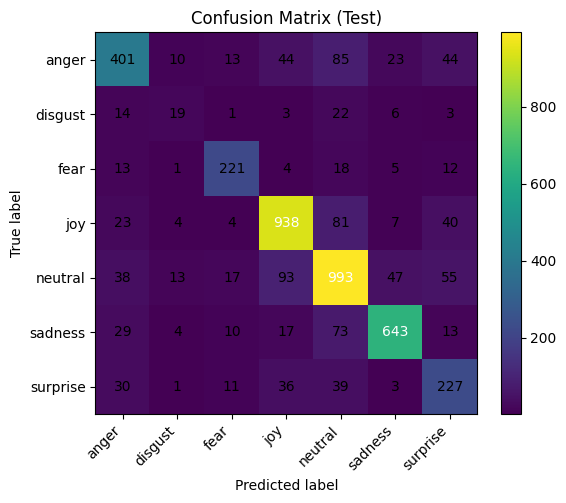

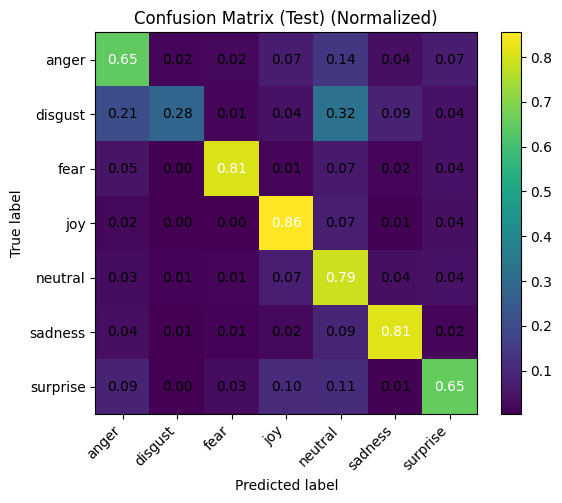

Saved to: /kaggle/working/confusion_matrix.png, /kaggle/working/confusion_matrix_normalized.png, /kaggle/working/confusion_matrix_raw.csv


In [3]:
# =========================
# Post-hoc evaluation cell
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

# 1) Get predictions on TEST
pred = trainer.predict(test_ds)
y_true = pred.label_ids
y_prob = pred.predictions
y_pred = y_prob.argmax(axis=-1)

# 2) Overall metrics
acc = accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

print(f"Accuracy: {acc:.4f}")
print(f"Macro  - Precision: {prec_macro:.4f} | Recall: {rec_macro:.4f} | F1: {f1_macro:.4f}")
print(f"Weighted - Precision: {prec_w:.4f} | Recall: {rec_w:.4f} | F1: {f1_w:.4f}\n")

# 3) Per-class report
print("=== Classification Report (per class) ===")
print(classification_report(y_true, y_pred, target_names=TARGET_LABELS, digits=4))

# 4) Confusion matrices (raw + normalized)
cm = confusion_matrix(y_true, y_pred, labels=range(len(TARGET_LABELS)))
cm_df = pd.DataFrame(cm, index=TARGET_LABELS, columns=TARGET_LABELS)
cm_df.to_csv("/kaggle/working/confusion_matrix_raw.csv", index=True)

def plot_cm(cm, labels, normalize=False, title="Confusion Matrix", fname=None):
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True).clip(min=1)
        cm_plot = cm.astype(float) / row_sums
    else:
        cm_plot = cm

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_plot, interpolation="nearest")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel="True label",
        xlabel="Predicted label",
        title=title if not normalize else f"{title} (Normalized)"
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    fmt = ".2f" if normalize else "d"
    thresh = cm_plot.max() / 2.0
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            ax.text(j, i, format(cm_plot[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm_plot[i, j] > thresh else "black")
    fig.tight_layout()
    if fname:
        plt.savefig(fname, bbox_inches="tight", dpi=150)
    plt.show()

plot_cm(cm, TARGET_LABELS, normalize=False,
        title="Confusion Matrix (Test)", fname="/kaggle/working/confusion_matrix.png")
plot_cm(cm, TARGET_LABELS, normalize=True,
        title="Confusion Matrix (Test)", fname="/kaggle/working/confusion_matrix_normalized.png")

print("Saved to:",
      "/kaggle/working/confusion_matrix.png,",
      "/kaggle/working/confusion_matrix_normalized.png,",
      "/kaggle/working/confusion_matrix_raw.csv")

In [4]:
!zip -r /kaggle/working/roberta-weighted-mrecall.zip /kaggle/working/roberta-weighted-mrecall

  adding: kaggle/working/roberta-weighted-mrecall/ (stored 0%)
  adding: kaggle/working/roberta-weighted-mrecall/checkpoint-28770/ (stored 0%)
  adding: kaggle/working/roberta-weighted-mrecall/checkpoint-28770/model.safetensors

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 9%)
  adding: kaggle/working/roberta-weighted-mrecall/checkpoint-28770/trainer_state.json (deflated 76%)
  adding: kaggle/working/roberta-weighted-mrecall/checkpoint-28770/tokenizer_config.json (deflated 76%)
  adding: kaggle/working/roberta-weighted-mrecall/checkpoint-28770/optimizer.pt (deflated 21%)
  adding: kaggle/working/roberta-weighted-mrecall/checkpoint-28770/config.json (deflated 54%)
  adding: kaggle/working/roberta-weighted-mrecall/checkpoint-28770/scheduler.pt (deflated 55%)
  adding: kaggle/working/roberta-weighted-mrecall/checkpoint-28770/merges.txt (deflated 53%)
  adding: kaggle/working/roberta-weighted-mrecall/checkpoint-28770/training_args.bin (deflated 51%)
  adding: kaggle/working/roberta-weighted-mrecall/checkpoint-28770/vocab.json (deflated 59%)
  adding: kaggle/working/roberta-weighted-mrecall/checkpoint-28770/tokenizer.json (deflated 72%)
  adding: kaggle/working/roberta-weighted-mrecall/checkpoint-28770/rng_state.pth (deflated 25%)
  adding: kaggle/